# Example Notebook "Gravitational Waves Data analysis" 2026

This example notebook starts with some basic introduction to gravitational-wave data analysis, and walks you through the detection and source characterisation of a real gravitational-wave event for the example of GW150914. The example notebook is meant to help you with the computing project in *'ProjectNotebook_DataAnalysis.ipynb'* (in which you'll perform analyses on real detector data from the recently completed fourth observing run of LIGO-Virgo-KAGRA. The tutorial session of 11 May is intended for discussion and working through the example notebook.

## Gravitational Wave Data Analysis: Techniques for Detection and Parameter Estimation

The detection and characterization of gravitational wave signals require sophisticated statistical and computational methods to extract weak signals from noisy interferometer data. This exercise focuses on two critical components of gravitational wave astronomy:

1.   **Matched Filtering** – A cornerstone of GW data analysis, matched  filtering maximizes the signal-to-noise ratio (SNR) by correlating detector data with theoretical waveform templates. We implement this using noise-weighted inner products and explore the effects of template mismatch on detection efficiency.
2.   **Bayesian Parameter Estimation** – After detection, we infer the astrophysical properties of compact binary coalescences (e.g., masses, spins, luminosity distance) through stochastic sampling of the posterior distribution. This involves likelihood evaluations with waveform models and noise power spectral densities.

### Tools and libraries

*   Bilby (Bayesian Inference Library) – A flexible framework for gravitational wave parameter estimation, supporting stochastic sampling (e.g., nested sampling via dynesty), marginalization over nuisance parameters, and conversion between waveform parameterizations. We use it to reconstruct the posterior distributions for GW150914. (for documentation and tutorial notebooks: https://github.com/bilby-dev/bilby)
*   PyCBC & LALSuite – Provides optimized implementations of matched filtering, template bank generation, and waveform models (e.g., IMRPhenomXP). These are essential for computing overlaps between data and templates in both time and frequency domains. (for documentation and tutorial notebooks: https://github.com/gwastro/pycbc, https://github.com/lscsoft/lalsuite)
*   GWpy – A Python package designed for working with gravitational wave time-series data. It provides tools for accessing, filtering, and visualizing data from gravitational wave detectors, making it ideal for signal analysis and preprocessing. (for documentation and tutorial notebooks: https://gwpy.github.io/docs/stable/)

### Methodology overview

In this notebook we discuss signal extraction by demonstrating:

*   The importance of matched filtering through injection of simulated GW signals in noise.
*   Signal extraction via time-domain and frequency-domain matched filtering.
*   Waveform systematics by quantifying SNR loss due to incorrect template parameters.
*   Application of matched filtering to detect real GW signals in LIGO data.
*   Bayesian inference of the source parameters of GW signals, leveraging Bilby’s stochastic sampling and convergence diagnostics.

These exercises mirror the LIGO-Virgo-KAGRA collaboration’s analysis pipeline, emphasizing the interplay between detection statistics and astrophysical inference.

Notebook by S. Lexmond, based on a collection of (modified) examples curated from several sources:

*   "Gravitational Waves meet Amplitudes in the Soutern Hemisphere" by P. Schmidt https://github.com/PatriciaSchmidt/AmplitudesTutorial
*   2023 Gravitational Wave Open Data Workshop: https://github.com/gw-odw/odw-2023/tree/main/Tutorials
*   GWpy docs: https://gwpy.github.io/docs/stable/
*   PyCBC docs: https://pycbc.org/pycbc/latest/html/
*   LALSuite docs: https://lscsoft.docs.ligo.org/lalsuite/lalsuite/index.html
*   Bilby docs: https://lscsoft.docs.ligo.org/bilby/index.html

We start by importing the needed packages. It is advised to always create a **new environment**!

In [2]:
# We first need to install a few code packages:
!pip install gwpy pycbc tensorflow scikit-image matplotlib numpy lalsuite bilby dynesty

from IPython.display import Math, HTML

# Introductary & example notebook (just for practise, not to be handed-in)

## 1. Matched filtering of simulated signals

This notebook walks you through a basic simulation and analysis workflow used in gravitational wave astronomy. You’ll simulate a binary black hole merger signal, inject it into simulated detector noise, and apply matched filtering to recover it. This technique forms the core of the signal detection methods used by the LIGO and Virgo collaborations.

In [3]:
# Before we begin, we import the necessary Python packages. We also suppress lower-level log messages to keep the output clean and focused.
import bilby
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt

bilby.core.utils.log.setup_logger(log_level="WARNING")

### Signal in the interferometer (Simulation of a GW150914-like signal)

Gravitational wave signals are typically analyzed in the frequency domain due to the stationary noise characteristics of detectors. Here we define the time and frequency arrays used for waveform generation and analysis.

We also impose a minimum frequency threshold (f_min) because detectors like LIGO are insensitive to very low-frequency signals due to seismic noise. The defined f_min is our lowest accurate frequency band measurement.

We also define the parameters of our binary black hole merger. These include the masses, spins, orientation angles, and distance to the source. While many of these parameters are set to simplified values, they collectively define the expected waveform using a theoretical model. (Here: "IMRPhenomXP", which is a computationally efficient inspiral-merger-ringdown model that includes effects of spin precession and is modeled directly in the frequency domain.)

We then generate the frequency-domain waveform using Bilby's waveform generator. This waveform represents the ideal signal we would expect in the absence of noise.

/Users/leayamashiro/anaconda3/lib/python3.11/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


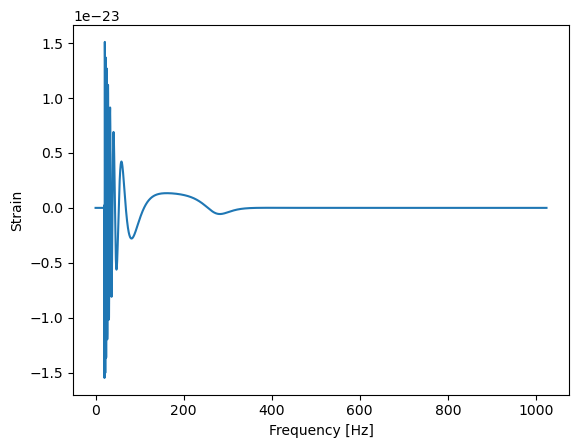

In [4]:
# create array of times at which to evaluate the waveform and corresponding frequency array at which to calculate its Fourier Transform

# minimum frequency threshold (detectors are insensitive to very low-freq signals due to seismic noise), 
# f_min is lowest accurate freq band measurement
f_min = 20. # in Hz 

sampling_frequency = 2048 # (s)
duration = 4 # duration (s)
start_time = 0 # arbitrary

# here you're just generating your empty set of time and frequency & sampling parameters 
time_frequency_series = bilby.core.series.CoupledTimeAndFrequencySeries(duration=duration,
                                                                        sampling_frequency=sampling_frequency,
                                                                        start_time=start_time)
frequency_array = time_frequency_series.frequency_array

# there is a minimum frequency below which the detector is not sensitive and we want to ignore them
frequency_mask = (frequency_array>= f_min)
time_array = time_frequency_series.time_array

#our example injection - parameters that are uninteresting for us are set to 0.
#Note that physically, amplitude is a function of the other parameters, mainly the distance
# this is set up as the form that needs to be input in waveform_generator.frequency_domain_strain(...)
injection_parameters = dict( 
    mass_1=36.0,
    mass_2=29.0,
    a_1=0.0, # spin magnitude of the primary
    a_2=0.0,
    tilt_1=0.0,
    tilt_2=0.0,
    phi_12=0,
    phi_jl=0,
    luminosity_distance=2000.0,
    theta_jn=0.0,
    psi=0,
    phase=0,
    geocent_time=0, 
    ra=0,
    dec=0,
    amplitude = 1e-21,
)
# ***** the only difference between the injection and the real signal is the geocent_time *****

approximant = "IMRPhenomXP" # computationally efficient inspiral merger ringdown model that includes effects of spin precession and modeled directly in freq domain
waveform_arguments = dict(
    reference_frequency=50.0,
    minimum_frequency=f_min,
    waveform_approximant=approximant # so this becomes IMRPhenomXP
)

# Create the waveform_generator. For our simple example it is quite unnecessary, but it is useful when we want to modify
# which approximant we use, what modes we want to produce and to control similar settings
waveform_generator_1 = bilby.gw.WaveformGenerator( # tells information about the object itself (binary black hole etc.) and this is the argument that it passes into the model 
    duration=duration,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole, # bilby built-in function to generate waveforms
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
)

waveform_1 = waveform_generator_1.frequency_domain_strain(parameters = injection_parameters)['plus']
# shift in time domain is modulation in frequency domain
time_shift = np.exp(2j*np.pi*frequency_array*injection_parameters['geocent_time'])
waveform_1*=time_shift

plt.plot(frequency_array, np.real(waveform_1))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Strain")
plt.show()

***Question 1: What is meant by the `geocent_time` and why are we generally performing this step when we create our injection? Explain the `time_shift` calculation.***

We simulate a single gravitational wave detector (LIGO Hanford, "H1") and inject our theoretical waveform into it. This step mimics how an astrophysical signal would appear in real interferometric data after accounting for the detector’s response function.

We also create a power spectral density (PSD) which characterizes the frequency-dependent sensitivity (or noise) of the detector.

---

#### Answer: 
```geocent_time```: 
- it's the is the arrival time of the gravitational wave signal at the geocenter (the center of the Earth), 
- measured in GPS seconds
- detectors like LIGO Hanford and Livingston are at different physical locations 
    - the signal arrives at each one at a slightly different time 
    - By using the geocenter as a common reference point, you can consistently define a single arrival time for the signal regardless of which detector you're working with 
    - Each detector's actual arrival time is then calculated from geocent_time plus a **small offset** *based on the detector's position and the sky location of the source* 


```time_shift = np.exp(2j*np.pi*frequency_array*injection_parameters['geocent_time'])```:
- A shift in the time domain corresponds to multiplying by a phase factor in the frequency domain 
    - (this is the Fourier shift theorem). 
- So this line is placing the waveform at the correct geocentric arrival time without having to work in the time domain directly.
---

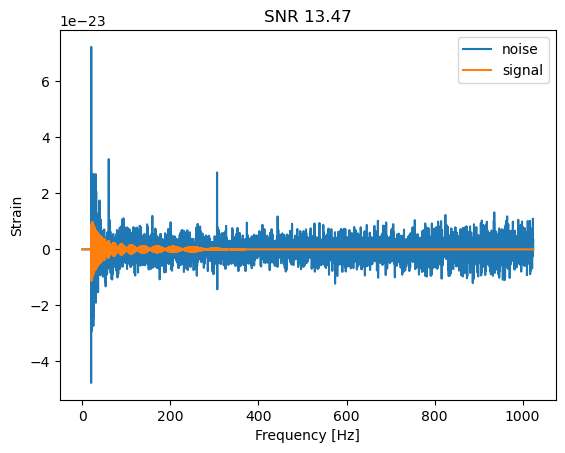

In [5]:
np.random.seed(1000)
injection_parameters = dict(
    mass_1=36.0,
    mass_2=29.0,
    a_1=0.0,
    a_2=0.0,
    tilt_1=0.0,
    tilt_2=0.0,
    phi_12=0,
    phi_jl=0,
    luminosity_distance=2000.0,
    theta_jn=0.0,
    psi=0,
    phase=0,
    geocent_time=2, # wait why 2 here? is this our "real signal"?
    ra=0,
    dec=0,
    amplitude = 1e-21,
)

# initializing an interferometer - for this exercise we only make 1. Here it is initialized empty
# ifo contains all detector specifics (gw signal is coming in the same at all detectors, but the detectors have other specifics)
# this is all of the characteristics of the detectors (H1 is Hanford)
ifos = bilby.gw.detector.InterferometerList(["H1"]) 
ifos.set_strain_data_from_zero_noise(
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=0,
)
# we grap the one-sided psd for use later 
# why is it one-sided PSD? 
# two sided PSD is where you allow it to have negative values (centered at 0) but this is just a product of doing the Fourier transform, 
# and you don't want the negative values, so you just take the one-sided one because negative values in freq space doesn't make sense
psd = ifos[0].power_spectral_density_array 

# inject signal (multiply waveform by detector response function)
ifos.inject_signal(
    waveform_generator=waveform_generator_1, parameters=injection_parameters
)

injected_strain = ifos[0].strain_data.frequency_domain_strain

#here we are getting a noise realization from the interferometer
ifos.set_strain_data_from_power_spectral_densities( # basically overwriting the strain using a different object!
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=0,
)
noise = ifos[0].strain_data.frequency_domain_strain # completely based on the PSD, which is detector-specific and given in ifo


plt.plot(frequency_array, np.real(noise), label = 'noise')
plt.plot(frequency_array, np.real(injected_strain), label = 'signal')
snr = np.abs(bilby.gw.utils.noise_weighted_inner_product(injected_strain, injected_strain, psd, duration = duration))**0.5

plt.title('SNR {:.2f}'.format(snr))
plt.legend()
plt.xlabel("Frequency [Hz]")
plt.ylabel("Strain")
plt.show()


In [ ]:
# can i get the normalized version of the waveform as well? 
waveform_1_normed = 

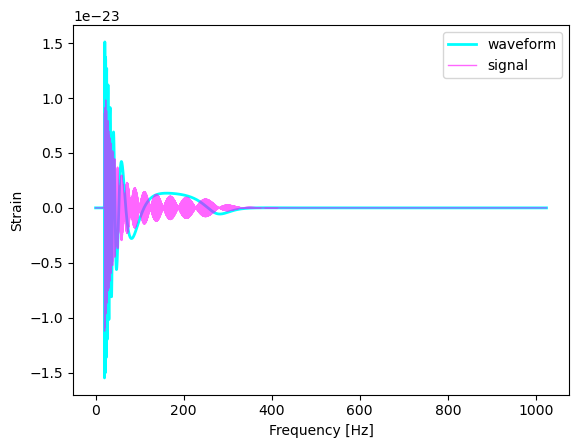

In [14]:
plt.plot(frequency_array, np.real(waveform_1), label = 'waveform', lw = 2, color = 'cyan')
plt.plot(frequency_array, np.real(injected_strain), label = 'signal', lw =1, alpha=0.6, color = 'magenta')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Strain")
plt.legend()
plt.show()

***Question 2: What information does the `ifo` object contain and how would this injection be different from other detectors like H1 and V1? How is the `injected_strain` different from the signal we generated in the previous cell?***

***Question 3: What kind of noise are we injecting in the code above? Explain how this noise is generated from the power spectral density (PSD). Why is this a good approximation to detector noise, and in what ways does it differ from real gravitational-wave detector noise? Be explicit about the assumptions made.***

***Question 4: Look at the calculation for the snr. Why are we comparing `injected_strain` with itself? What are we actually calculating here and why is this a valuable test?***

---

In [36]:
def print_ifos_object(ifo_obj): 
    '''
    function to print a vertical list all of the values in the ifos object
    '''
    for key, value in vars(ifo_obj[0]).items():
        if hasattr(value, '__dict__'):
            print(f"{key}:")
            for sub_key, sub_value in vars(value).items():
                print(f"  {sub_key}: {sub_value}")
        else:
            print(f"{key}: {value}")

print_ifos_object(ifos)
    

geometry:
  _x_updated: True
  _y_updated: True
  _vertex_updated: True
  _detector_tensor_updated: True
  length: 4
  _latitude: 0.8107952638302021
  _longitude: -2.084056769166123
  _elevation: 142.554
  _xarm_azimuth: 2.199104385537343
  _yarm_azimuth: 3.7699007123322397
  _xarm_tilt: -0.0006195
  _yarm_tilt: 1.25e-05
  _vertex: [-2161414.92636    -3834695.17888835  4600350.22663899]
  _x: [-0.22389266  0.79983063  0.55690488]
  _y: [-0.91397819  0.02609404 -0.40492342]
  _detector_tensor: [[-0.3926141  -0.07761341 -0.24738904]
 [-0.07761341  0.31952407  0.22799783]
 [-0.24738904  0.22799783  0.07309003]]
name: H1
power_spectral_density:
  _cache: {'frequency_array': array([0.00000e+00, 2.50000e-01, 5.00000e-01, ..., 1.02350e+03,
       1.02375e+03, 1.02400e+03]), 'psd_array': array([           inf,            inf,            inf, ...,
       2.13422813e-47, 2.13478325e-47, 2.13540351e-47]), 'asd_array': array([           inf,            inf,            inf, ...,
       4.61977069e-

---

***Question 2: What information does the `ifo` object contain and how would this injection be different from other detectors like H1 and V1? How is the `injected_strain` different from the signal we generated in the previous cell?***

#### Answer Question 2: 
*What information does the `ifo` object contain and how would this injection be different from other detectors like H1 and V1?* 
- ifo object contains all information about the interferometer (like position etc.) 
- but then also contains information about the detector after you have injected the signal (after you do ```ifos.inject_signal(...)```)
- would be different from other detectors like H1 & V1: 
    - the different interferometers have different positional and noise attributes 

*How is the `injected_strain` different from the signal we generated in the previous cell?*
- the first cell is just the bare waveform
- the second step is using the ifo (using the interferometer) and overwriting the strain using the ifo parameters

---

***Question 3: What kind of noise are we injecting in the code above? Explain how this noise is generated from the power spectral density (PSD). Why is this a good approximation to detector noise, and in what ways does it differ from real gravitational-wave detector noise? Be explicit about the assumptions made.***

#### Answer Question 3: 

*What kind of noise are we injecting in the code above? Explain how this noise is generated from the power spectral density (PSD).*



In [1]:
plt.hist(np.real(noise))
plt.xlabel('freq')
plt.ylabel('prob')

NameError: name 'plt' is not defined

In reality, detector data is noisy. Here, we simulate that noise based on the PSD and add it to our injected signal. This provides a realistic dataset for performing signal detection.

/Users/leayamashiro/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/leayamashiro/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


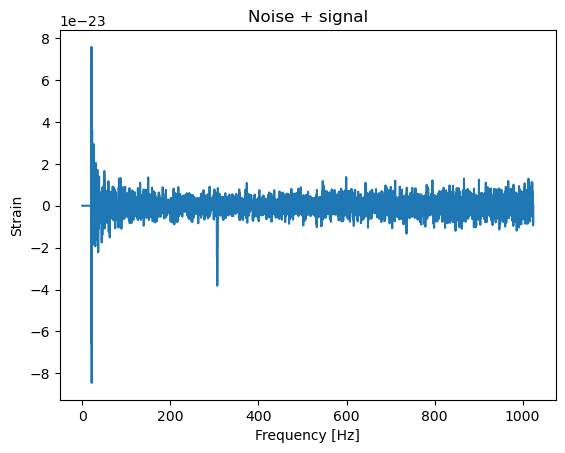

In [42]:
data = noise+injected_strain
plt.plot(frequency_array, data)
plt.title('Noise + signal')

plt.xlabel("Frequency [Hz]")
plt.ylabel("Strain")
plt.show()

Even though a human eye cannot recognize a signal from the noise, we can be pretty sure it is there. It requires some non-obvious data analysis techniques, one of which is matched filtering.

Matched filtering is a technique that compares the noisy data with a theoretical template to extract the signal. It weights the signal according to the detector’s sensitivity across frequencies.

We compute the optimal matched-filter SNR to quantify how “loud” the signal is relative to the noise. A value above 8.0 is typically considered sufficient for detection. Our simulated signal has an SNR of ~14, so it should be detectable even though it’s visually buried in noise. Let's move on to a closer look on matched filtering!

For completeness, here are signal and noise in the time domain:

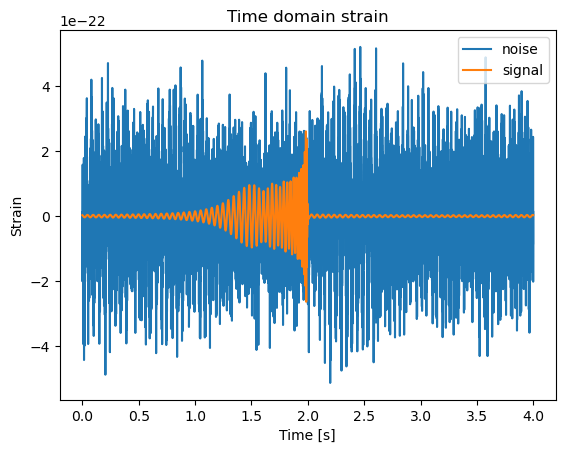

In [44]:
# doing the inverse fourier transform to put back into time domain

time_domain_noise = bilby.utils.infft(
    noise, sampling_frequency)
time_domain_signal = bilby.utils.infft(
    injected_strain, sampling_frequency)

plt.plot(time_array, time_domain_noise, label = 'noise')
plt.plot(time_array, time_domain_signal, label = 'signal')
plt.title('Time domain strain')
plt.legend()
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.show()

### Matched filtering

To decide if the signal is present in the interferometer, we create a detection statistics. For our purpose, it will be:
\begin{equation*}
\rho(t_0) \equiv \langle s | \hat{h} \rangle\,,
\end{equation*}
where $\hat{h} = h/\sqrt{\langle h | h \rangle}$. It is a normalized waveform template for some choice of parameters $\theta$. $\langle \cdot | \cdot \rangle$ is the noise-weighted inner product. With this detection statistics, we can make a rudimentary matched filtering algorithm below. At the beginning, we are assuming that we know all the parameters perfectly (we assume that the signal has either a precise value of component masses and other parameters, or there is no signal at all), with just `geocent_time` that we want to find. The plan of action is obvious:
1. Create templates $\hat{h}(t_c)$ for different times of coalescence.
2. For each template, calculate the detection statistics with the data.
3. Find $t_c$ that gives the maximum detection statistics $\rho$ - this is the inferred time of the signal.
4. In general we would consider it detection only if the detection statistics reached some predetermined theshold. We would simulate a big data set of just noise and see how often a given detection statistics would be reached by chance alone. This would allow us to connect detection statistic with false alarm probability.

8192it [00:00, 8485.83it/s]


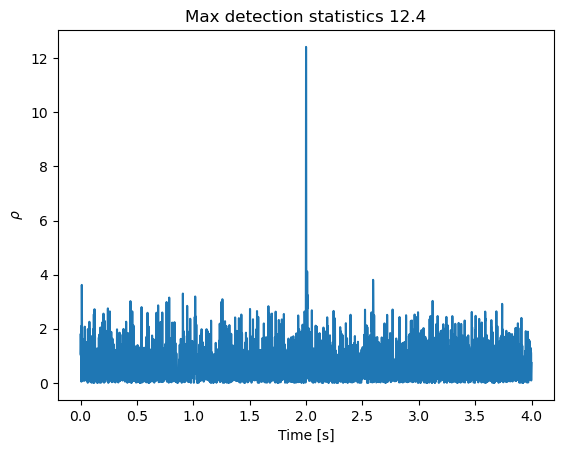

In [45]:
# from the earlier parts of the notebook:
# f_min = 20. # in Hz
# sampling_frequency = 2048 # (s)
# duration = 4 # duration (s)
# start_time = 0 # arbitrary
# time_frequency_series = bilby.core.series.CoupledTimeAndFrequencySeries(duration=duration,
#                                                                         sampling_frequency=sampling_frequency,
#                                                                         start_time=start_time)

# time_array = time_frequency_series.time_array

# Start again from geocent t=0 and create multiple templates with time_shifted waveforms.
template_parameters = dict(
    mass_1=36.0,
    mass_2=29.0,
    a_1=0.0,
    a_2=0.0,
    tilt_1=0.0,
    tilt_2=0.0,
    phi_12=0,
    phi_jl=0,
    luminosity_distance=2000.0,
    theta_jn=0.0,
    psi=0,
    phase=0,
    geocent_time=0,
    ra=0,
    dec=0,
    amplitude = 1e-21,
)

ifos.set_strain_data_from_zero_noise(
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=0,
)

ifos.inject_signal(
    waveform_generator=waveform_generator_1, parameters=template_parameters
)
template = ifos[0].strain_data.frequency_domain_strain

#normalize template to length 1
template /= np.abs(bilby.gw.utils.noise_weighted_inner_product(template, template, psd, duration = duration))**0.5


n = len(time_array)
statistics_array = np.zeros(n, dtype='complex')

#we loop over every distinct time (we do not take in the data continously, so there are only so many possible choices)
for i, time in tqdm(enumerate(time_array)):
    time_shift = np.exp(2j*np.pi*frequency_array*time)
    shifted_template = template*time_shift
    # data = noise + injected_strain
    statistics_array[i] = np.real(bilby.gw.utils.noise_weighted_inner_product(data, shifted_template, psd, duration = duration))

plt.plot(time_array, np.abs(statistics_array))
plt.title("Max detection statistics {:.1f}".format(np.max(np.abs(statistics_array))))
plt.ylabel(r"$\rho$")
plt.xlabel("Time [s]")
plt.show()

***Question 5: Why is it necessary to normalize the template when computing the SNR in this case, and why was this normalization not required in earlier calculations?***

***Question 6: At what `geocent_time` did you expect the highest snr?***

### Realistic matched filtering (Maximizing over time and phase)

## Maximizing over time and phase

The method we used above is conceptually simple, but inefficient. If we were to apply it directly to real data, we would proceed as follows:

1. Construct a grid over parameters such as chirp mass $M_c$, mass ratio $q$, coalescence time $t_c$, and phase.
2. Generate a template waveform for each point in this grid.
3. Compute the matched filter (inner product) between the data and each template.
4. Select the parameters that give the highest match.

This approach quickly becomes computationally expensive, especially because we must repeat the calculation for many possible values of time and phase.

However, time and phase are special parameters. They do not change the intrinsic shape of the waveform, only:

- when the signal occurs (time shift), and  
- how it is rotated in phase.

Because of this, they are often treated as nuisance parameters. Instead of explicitly looping over them, we can handle them analytically and compute the match much more efficiently.

---


Instead of computing the match over all the templates seperately, we can combine the efforts in a smart way that calculates the match for all templates simultaniously.

We define the matched filter as:

$$
\rho(t_0) = \langle d | h(t - t_0) \rangle
$$

This represents the overlap between the data $d$ and a template shifted by time $t_0$.

In the frequency domain, a time shift corresponds to multiplication by a complex exponential:

$$
h(t - t_0) \;\longrightarrow\; \hat{h}(f)\, e^{-2\pi i f t_0}
$$

Substituting this into the inner product gives:

$$
\rho(t_0) = \int df \, \frac{\hat{d}^*(f)\,\hat{h}(f)}{S(f)} \, e^{-2\pi i f t_0}
$$

Now observe that this expression has the form of an inverse Fourier transform. Therefore:

$$
\rho(t_0) = \mathcal{F}^{-1} \left( \frac{\hat{d}^*(f)\hat{h}(f)}{S(f)} \right)(t_0)
$$

---


Instead of computing the inner product separately for every possible time shift, we can:

1. Compute the quantity
   $$
   Q(f) = \frac{\hat{d}^*(f)\,\hat{h}(f)}{S(f)}
   $$

2. Perform a single inverse Fourier transform:
   $$
   \rho(t) = \mathcal{F}^{-1}(Q(f))
   $$

3. Find the time $t_0$ where $\rho(t)$ is maximized.

This gives the matched-filter output for all possible time shifts at once. The FFT algorithm avoids explicit looping over time and much more efficient.


***Question 7: Why are extrinsic parameters like phase and time coalescence much easier to estimate than intirnsic parameters like spin? Can we use the same FFT trick for intrinsic parameters?***

Let's calculate the SNR with our new match calculation.

In [ ]:

template_parameters = dict(
    mass_1=36.0,
    mass_2=29.0,
    a_1=0.0,
    a_2=0.0,
    tilt_1=0.0,
    tilt_2=0.0,
    phi_12=0,
    phi_jl=0,
    luminosity_distance=2000.0,
    theta_jn=0.0,
    psi=0,
    phase=0,
    geocent_time=0,
    ra=0,
    dec=0,
    amplitude = 1e-21,
)

ifos.set_strain_data_from_zero_noise(
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=0,
)

ifos.inject_signal(
    waveform_generator=waveform_generator_1, parameters=template_parameters
)
template = ifos[0].strain_data.frequency_domain_strain

#normalize template
template /= np.abs(bilby.gw.utils.noise_weighted_inner_product(template, template, psd, duration = duration))**0.5

match = 2*np.conj(data)*template/psd
time_domain_match = bilby.utils.infft(
    match, sampling_frequency)

plt.plot(time_array, np.abs(time_domain_match))
plt.xlabel("Time (s)")
plt.show()

Then we just take this maximum to value from the plot above to be the detection statistics with a given template. This method works much faster than the previous one.

**TO DO: Injecting a simulated signal with precessing spins and using a non-spinning template for detection.**

We have so far assumed that the components in our GW150914-like binary black hole merger simulation are non-spinning, and have constructed the simulated signal and the template accordingly. (That is a reasonable simplifcation, since the LIGO-Virgo data analysis of GW150914 did not provide evidence for large spins.)

Assuming now a GW150914-like binary black hole merger with large spin magnitudes that are misaligned with the orbital angular momentum: how do the matched filter results change when we inject a signal with spin-precession and continue using a template with zero spins (i.e., an insufficiently complex model) for matched filtering? How much SNR do we lose? (You can try different spin magnitudes and tilt angles for your injection.)

***Question 8: What would be an example of precessing spins with large spin magnitudes?***

***Question 9: Do some research. Are there other binary features that can be mistakenly identified as precession? We call this degeneracy. Explain what causes the degeneracy between precession and these other parameters.***

In [ ]:
# Visualize the different waveform morphology for zero-spin and spin-precessing signal simulations, in frequency and time domain.
# Use a zero-spin template to detect a spin-precessing GW150914-like signal injected in simulated detector noise, using the efficient matched-filter method from above.
# How much SNR do you lose? (Try different values of spin magnitudes and tilt angles.)

injection_parameters = dict(
    mass_1=36.0,
    mass_2=29.0,
    a_1=### YOUR CODE HERE,
    a_2=### YOUR CODE HERE,
    tilt_1=### YOUR CODE HERE,
    tilt_2=### YOUR CODE HERE,
    phi_12=0,
    phi_jl=0,
    luminosity_distance=2000.0,
    theta_jn=0.0,
    psi=0,
    phase=0,
    geocent_time=2,
    ra=0,
    dec=0,
    amplitude = 1e-21,
)

### YOUR CODE HERE.

### Realistic matched filtering (Using "banks" of templates)

Now that we can compute the matched filter output efficiently, we can scale up our analysis. In a realistic data analysis scenario, we don't know the exact source paramters of the binary black hole GW signal hidden in the detector data. So we need to build a "template bank" for detection: a collection of waveform templates with different masses and spins of the component black holes. Those are then all tried as matched filters on the data.

In this step, we:

* Create a set of 1000 templates with different chirp masses $\mathcal{M}=\frac{(m_1*m_2)^{3/5}}{(m_1+m_2)^{1/5}}$ around that of GW150914 ($\sim 30 M_\odot$), keeping the mass ratio fixed to $q=m_1/m_2 = 1$ and all other waveform parameters unchanged.
* Use the fast matched filtering method from above for each template.
* Record the maximum detection statistic (SNR) obtained with each.

Plotting the maximum detection statistic of each filter against its chirp mass shows a clear peak at the injected chirp mass. This proves that we can detect a GW signal in the data with only the assumption that our source is a binary black hole merger, without prior knowledge of the true parameters, by identifying the "best-fit template" amongst a collection of filters. (Crucially, this method will work no matter what time shift of the base template we set.)

**TO DO: Construct a template bank and use it for matched filtering; identify the best-fit template in the bank.**

For simplicity, you can return to the previous scenario where both the injected signal and the templates we use assume zero spins.

In [ ]:
"""Build a template bank consisting of 1000 linearly spaced templates. Find the maximum detection statistics and find the true parameters. """

# Make 1000 linearly spaced templates for chirp masses between 15 and 100 M_\odot
# Keep the mass ratio the same! You can use bilby.gw.conversion.chirp_mass_and_mass_ratio_to_component_masses() to calculate mass_1 and mass_2
### YOUR CODE HERE

# Iterate over templates with different chirp masses to calculate the template matches
### YOUR CODE HERE

# Plot the chirp mass values against their best match time-domain SNR for each of the templates.
### YOUR CODE HERE

Note: In a realistic search for unknown GW signals from compact binary mergers in LIGO-Virgo data, we would use a template bank with $\mathcal{O}(10^5)$ templates, spanning the parameter space of masses from a few to a few hundred $M_\odot$ and spins between $0$ and $1$.

## 2. Matched filtering of a real GW event from LIGO data

### Example: GW150914

Using a matched-filter algorithm like the one we've just built, we now search LIGO data for the first directly detected GW signal GW150914 (the first observation of a binary black hole merger).

Work through the example below, and then try to apply a similar procedure to one of the GW events from the recently published Gravitational Wave Transient Catalog 4.0 including O4a observations (GWTC-4: arxiv.org/abs/2508.18082).

In [ ]:
import bilby
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps

We begin by initializing empty interferometer objects for the two LIGO detectors: Hanford (H1) and Livingston (L1). These objects will later be populated with strain data and noise characteristics.

Note: Virgo was not contributing to GWTC-4 observations, so you don't need to consider it for your subsequent analysis of a GWTC-4 event.

In [ ]:
# The first step in the analysis is to set up our detector network by initialising the (empty) detector objects

H1 = bilby.gw.detector.get_empty_interferometer("H1")
L1 = bilby.gw.detector.get_empty_interferometer("L1")

We specify a time segment around the GW150914 event to analyze. We load the strain data from both detectors using gwpy, fetching publicly available LIGO data. We also plot the time series to visually inspect the stretch of data we'll be working with.

In [ ]:
# Let's retrieve the time and data of a GW event in a published catalog (example: GW150914):
gps = event_gps('GW150914')
print("The GPS time of GW150914:", gps)

In [ ]:
# Load the data you want to analyse
# First, we define the times we want to analyse relative to the time of the event
# Real LIGO data has a higher sampling frequency than the one we previously used, so we need to update our settings accordingly.

# Take 2 seconds before and after the trigger time, to have a good chunk of data to analyse.
# Use gwpy to fetch the open data.
# fetching open data: https://gwpy.github.io/docs/2.1.1/timeseries/opendata/

sampling_frequency = 4096 # (s)
duration = 4.0
analysis_start = # in GPS time

# Use gwpy to fetch the open data for the Hanford and Livingston detectors.
# Set cache=True for faster loading if you run the notebook multiple times.
H1_analysis_data = #

L1_analysis_data = #

In [ ]:
# Let's visualise the stretch of data we will be analysing

# Plot the data for both detectors in the time domain
######### Code goes here #########

Next, we assign the fetched strain data to our interferometer objects. These objects now contain both the raw data and metadata required for analysis.

In [ ]:
# We now pass the strain data we want to analyse to the interferometer objects

H1.set_strain_data_from_gwpy_timeseries(H1_analysis_data)
L1.set_strain_data_from_gwpy_timeseries(L1_analysis_data)

Matched-filter searches (and subsequently parameter estimation) require a good model of the noise, which is characterized by the power spectral density (PSD). We fetch a longer segment of data prior to the signal. The prior segment will contain a good estimate of the noise, because it was measured around the same time as the signal (of course assuming there was no other overlapping signal immediately before. This might not be such a sharp assumption for future detectors.).

After extracting a noise segment, we use gwpy's Welch method to compute the PSD by using the segment information. The PSD is a statistical property of the noise, so we estimate it by averaging over many noisy segments. This step is essential for calculating SNRs (and later likelihoods) accurately.

In [ ]:
# We generate the noise power spectral density using the Welch method as implemented in gwpy
# This requires us to download a longer stretch of data than the data we analyse

psd_duration = duration * 32
psd_start_time = analysis_start - psd_duration

H1_psd_data = TimeSeries.fetch_open_data(
    "H1", psd_start_time, psd_start_time + psd_duration, sample_rate=4096, cache=True)

L1_psd_data = TimeSeries.fetch_open_data(
    "L1", psd_start_time, psd_start_time + psd_duration, sample_rate=4096, cache=True)

In [ ]:
# We use gwpy to generate the PSD
psd_alpha = 2.0 * H1.strain_data.roll_off / duration

H1_psd = H1_psd_data.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
L1_psd = L1_psd_data.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")

In [ ]:
# Now that we have the PSD, we store it in our interferometer objects

H1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1_psd.frequencies.value, psd_array=H1_psd.value)

L1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1_psd.frequencies.value, psd_array=L1_psd.value)

***Question 10: What happens when there is a huge glitch in the seconds before the signal? Look at the `psd()` function. How are these issues currently being handled?***

We compare the frequency-domain strain data with the amplitude spectral density (the square root of the PSD) to confirm the validity of the PSD estimate. This plot helps us understand how noise varies with frequency.

In [ ]:
# Let's visualise the strain data and the amplitude spectral density (ASD) = \sqrt(PSD)

fig, ax = plt.subplots()
idxs = H1.strain_data.frequency_mask  # This is a boolean mask of the frequencies which we'll use in the analysis
ax.loglog(H1.strain_data.frequency_array[idxs],
          np.abs(H1.strain_data.frequency_domain_strain[idxs]), label='Strain')
ax.loglog(H1.power_spectral_density.frequency_array[idxs],
          H1.power_spectral_density.asd_array[idxs], label='ASD')
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Strain [1/$\sqrt{Hz}$]")
ax.legend()
plt.show()

We now apply a template (construced from a waveform model using the true parameters of GW150914) to matched-filter the LIGO-Hanford data and identify the GW event in the noisy data.


In [ ]:
# Real LIGO data has a higher sampling frequency than the one we previously used
f_min = 20. # in Hz
sampling_frequency = 4096 # (s)
duration = 4 # duration (s)
start_time = 0 # arbitrary

# Create a new time array & re-initialize the waveform_generator with the increased sampling_frequency
time_frequency_series_new = bilby.core.series.CoupledTimeAndFrequencySeries(duration=duration,
                                                                        sampling_frequency=sampling_frequency,
                                                                        start_time=start_time)
time_array_new = time_frequency_series_new.time_array

waveform_generator_2 = bilby.gw.WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
)

# Empty H1 detector object (to project template onto H1)
H1_proj = bilby.gw.detector.get_empty_interferometer("H1")

# Detector data and PSD from real event
H1_proj.set_strain_data_from_gwpy_timeseries(H1_analysis_data)
data_H1 = H1_proj.strain_data.frequency_domain_strain
psd_H1 = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1_psd.frequencies.value, psd_array=H1_psd.value)

# Generate a template (using the published parameters of the real event) [simplification used here: zero spins and other parameters]
template_parameters = dict(
    mass_1=36.0,
    mass_2=29.0,
    a_1=0.0,
    a_2=0.0,
    tilt_1=0.0,
    tilt_2=0.0,
    phi_12=0,
    phi_jl=0,
    luminosity_distance=2000.0,
    theta_jn=0.0,
    psi=0,
    phase=0,
    geocent_time=0,
    ra=0,
    dec=0,
)
# Multiply template by H1 antenna reponse pattern function
H1_proj.set_strain_data_from_zero_noise(
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=0)
H1_proj.inject_signal(
    waveform_generator=waveform_generator_2, parameters=template_parameters)
template_H1 = H1_proj.strain_data.frequency_domain_strain

#normalize template
template_H1 /= np.abs(bilby.gw.utils.noise_weighted_inner_product(template_H1, template_H1, psd_H1.psd_array, duration = duration))**0.5

# Matched filtering of H1 data from real event
# Perform the matched filtering between actual data and the template using the efficient method we implemented above (or using bilby's built-in matched filtering function).
### YOUR CODE HERE

# Plot the time-domain matched filter output and indicate the maximum detection statistic on the plot.
### YOUR CODE HERE


***Question 11: What does the SNR look like for the Livingston detector? Which detector had a better performance? What factors could be responsible for this?***

We have now detected GW150914 in the LIGO data.

## 3. Parameter estimation for a real GW source  

### Example: GW150914  

In gravitational-wave astronomy, detecting a signal is only the beginning. Once a signal has been confidently identified using matched filtering with a template bank, the next crucial step is to accurately infer the physical properties of the source—such as the masses, spins, distance, and orientation of the binary system. This process is known as **parameter estimation**.

Matched filtering and parameter estimation are closely related but serve different purposes. In matched filtering, we correlate the detector data with a large set of templates to search for signals and identify which template produces the highest signal-to-noise ratio (SNR). This provides a **detection statistic** and a rough indication of the source parameters (e.g., which chirp mass gives the strongest match). However, this approach typically explores the parameter space in a coarse and discrete way.

Parameter estimation, by contrast, is a **Bayesian inference problem**. Instead of selecting the single best-matching template, we evaluate how well *all possible parameter combinations* explain the data. This is done by defining a likelihood function (which is closely related to the matched-filter inner product) and combining it with prior distributions to obtain a **posterior distribution** over the parameters. Rather than a single best-fit value, we obtain probability distributions that quantify uncertainties and correlations between parameters.

In practice, parameter estimation builds directly on the matched-filtering framework: the likelihood used in Bayesian inference is derived from the same noise-weighted inner product that defines the matched-filter SNR. The key difference is that instead of maximizing this quantity over a discrete template bank, we **stochastically sample the continuous parameter space** using algorithms such as nested sampling or MCMC.

In this example, we perform a basic parameter estimation analysis of GW150914, continuing to use the open LIGO data (and PSDs) we have already fetched, together with the Bilby software library.

Next, we define prior probability distributions for the parameters we want to infer. For simplicity, we use uniform priors over plausible astrophysical ranges for most parameters, and fix others like spin and orientation to known values for this short example. These priors represent our beliefs about the parameters before looking at the data.

To keep the dimensionality of the sampling space (and the computational cost) manageable, we assume that the black holes have zero spin.

***Question 12: Can you think of any reasons to use a non-uniform prior in parameter estimation?***

In [ ]:
import bilby
from bilby.core.prior import Uniform, PowerLaw
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters, generate_all_bbh_parameters

# Next we set up a prior for the analysis

prior = bilby.core.prior.PriorDict()
prior = bilby.core.prior.PriorDict()
# prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=###, maximum=###)  # <-- FILL IN
# prior['mass_ratio'] = Uniform(name='mass_ratio', minimum=###, maximum=###)  # <-- FILL IN
prior['phase'] = Uniform(name="phase", minimum=0, maximum=2*np.pi)
prior['geocent_time'] = Uniform(name="geocent_time", minimum=gps-0.1, maximum=gps+0.1)
prior['a_1'] =  0.0
prior['a_2'] =  0.0
prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0
prior['dec'] =  -1.2232
prior['ra'] =  2.19432
prior['theta_jn'] =  1.89694
prior['psi'] =  0.532268
prior['luminosity_distance'] = PowerLaw(alpha=2, name='luminosity_distance', minimum=50, maximum=2000, unit='Mpc', latex_label='$d_L$')

We now define the likelihood function, which quantifies how well a set of parameters explains the observed data. This is done using `GravitationalWaveTransient`, which compares the strain data to model waveforms. We also enable marginalization over nuisance parameters like phase, time, and distance to speed up sampling.

To generate model waveforms, we use the waveform approximant (`IMRPhenomXP`) as before. The waveform generator will convert sampled parameters into a frequency-domain waveform that can be compared with the data (by way of matched filtering).

In [ ]:
# The next step is to set up the likelihood object that evaluates the likelihood between some waveform model (template)
# and the strain data we are analysing

# First, we set up the list of interferometers we want to include in the likelihood calculation
interferometers = [H1, L1]

# Next we need set up the waveform generator that can specify templates at a random point in parameter space
waveform_arguments = dict(
    waveform_approximant='IMRPhenomXP', reference_frequency=100., catch_waveform_errors=True)

# We now create the waveform_generator object. This also takes care of converting between parameters etc.
waveform_generator = bilby.gw.WaveformGenerator(
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    waveform_arguments=waveform_arguments,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters)

# Finally, we create the likelihood using the GravitationalWaveTransient class
likelihood = bilby.gw.likelihood.GravitationalWaveTransient(
    interferometers, waveform_generator, priors=prior,
    time_marginalization=True, phase_marginalization=True, distance_marginalization=True)

We run the nested sampler dynesty to explore the posterior distribution. For speed, we use a relatively small number of live points (`nlive=250`) and a loose convergence threshold (`dlogz=1.`). These settings are acceptable for demonstration but would need to be tightened for publication-quality results.

**TO DO: Run the sampler for different `nlive` and `dlogz`. How does this effect the result and run-time?**

In [ ]:
# Let's get sampling!

# Run the sampler and observe runtime, posterior width, etc.
result_short = bilby.run_sampler(
    likelihood,
    prior,
    sampler='dynesty',
    outdir='short',
    label="GW150914",
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    nlive=250,        # <-- Try 250 vs 500
    dlogz=1,        # <-- Try 1 vs 0.5
    clean=True,
)

***Question 13: What are you actually changing when you adjust the `nlive` and `dlogz`parameters? Why would you make certain choices?***

***Question 14: What sampling technique are you using in the above cell? Are there other sampling techniques you could use? What are the advantages/disadvantages?***

Once sampling is complete, we access the posterior samples as a Pandas DataFrame. We extract the total mass of the system and compute summary statistics such as the median and 90% credible interval.

We visualize the posterior distribution with a histogram and a corner plot showing joint distributions of selected parameters. These results tell us what values of the parameters are most consistent with the observed data, and how certain we are about them.

**TO DO: Compute & display the median and 90% credible interval of posterior  distributions.**

**TO DO: Produce histograms and contour plots for other source parameters (individual masses, distance). Are they well-constrained? Correlated?**  

In [ ]:
# The posterior samples for all parameters are stored as panda data frames.
# Including converted parameters and computed SNR and likelihood values for each sample.
result_short.posterior.keys()

In [ ]:
# Full list of samples:
result_short.posterior

In [ ]:
# Compute the 90% credible interval and the median of the distribution for the chirp mass and mass ratio.

# Use np.quantile to get 5%, 50%, 95% intervals
Mchirp = result_short.posterior["chirp_mass"].values
q = result_short.posterior["mass_ratio"].values

# Calculate the 5%, 50%, 95% quantiles of the total mass distribution and plot the histograms with clear indication of the credible intervals.
lower_bound = ### YOUR CODE HERE
median = ### YOUR CODE HERE
upper_bound = ### YOUR CODE HERE

# Plot your histogram of the total mass distribution and indicate the credible intervals on the plot.
### YOUR CODE HERE

***Question 15: Do the resulting posterior distributions appear consistent with the chosen priors? Additionally, do any of the parameters show signs of railing, where the posterior accumulates at the boundaries of the prior? Should any of the prior ranges be adjusted?***

In [ ]:
# 1D and 2D posteriors for the chirp mass and mass ratio.
result_short.plot_corner(parameters=["chirp_mass", "mass_ratio", "luminosity_distance"], prior=True)


***Question 16: In the corner plot: What do the diagonal and off-diagonal distributions represent?***